# Module 2: Whole-Genome-Style Somatic Analysis, Structural Variants and Copy Number

## What this notebook does, in plain language

Whole-exome sequencing (Module 1) only reads the protein-coding 1-2% of the genome. That
is enough to find point mutations and small insertions/deletions in genes, but it misses
an entire category of cancer-relevant change: large-scale rearrangements of the genome
itself. A cancer cell's DNA can be cut, flipped, duplicated, or deleted in chunks
thousands to millions of DNA letters long, changes an exome simply cannot see, because it
only samples small, scattered windows of the genome rather than the continuous sequence
in between.

This notebook covers the two things whole-genome-style sequencing adds that exome
sequencing cannot provide:

- **Structural variants (SVs):** large deletions, duplications, inversions, and
  translocations, found by a tool called Manta.
- **Copy-number alterations (CNAs):** regions where the tumor has gained or lost whole
  copies of a chromosome segment, found by a tool called CNVkit.

Both are run on **chr9 and chr20 only**, whole chromosomes, not just their genes, the same
resource-constrained scope explained in the project README. chr20 was picked as a clean,
moderate-size chromosome; chr9 was picked specifically because it carries **CDKN2A**, a
tumor-suppressor gene very frequently deactivated in melanoma, often by exactly the kind
of large deletion this notebook is set up to detect.

## Where the inputs live and what the outputs look like

This notebook expects `pipelines/wgs/main.nf` to have already been run. It reads:

- `data/processed/wgs/COLO829T_vs_COLO829R.filtered.vcf.gz`, somatic SNVs/indels called
  genome-wide within chr9+chr20 (no exome restriction this time)
- `results/wgs/benchmark/COLO829T_vs_COLO829R.happy.summary.csv`
- `data/processed/wgs/COLO829T_vs_COLO829R.manta.somaticSV.vcf.gz`, Manta's structural
  variant calls
- `results/wgs/benchmark/COLO829T_vs_COLO829R_truvari/summary.json`, the SV
  benchmarking result
- `data/processed/wgs/COLO829T_vs_COLO829R.call.cns`, CNVkit's discrete copy-number
  calls
- `results/wgs/benchmark/COLO829T_vs_COLO829R.cnvkit_vs_bicseq.overlap.tsv` and
  `....cnvkit_vs_svtruth_delDup.overlap.tsv`, the CNV concordance comparisons

It writes figures to `results/figures/`, including
`wgs-copy-number-profile-chr9-chr20.png`.


In [3]:
import json as jsonlib
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO_ROOT = Path("..")
PROCESSED_DIR = REPO_ROOT / "data" / "processed" / "wgs"
BENCHMARK_DIR = REPO_ROOT / "results" / "wgs" / "benchmark"
FIGURES_DIR = REPO_ROOT / "results" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

SAMPLE_PAIR = "COLO829T_vs_COLO829R"


## Part 1: SNVs and indels, this time genome-wide within chr9+chr20

Module 1 restricted Mutect2 to exome regions only. This pipeline runs the exact same
Mutect2 and filtering steps but without that restriction, across the whole extent of
chr9 and chr20. The benchmarking method is identical to Module 1 (hap.py against the
same truth set), just over a larger comparison region, so this section is intentionally
brief; see Module 1's notebook for a full explanation of what Mutect2 and hap.py are
doing.

One difference worth expecting going in: WES data is sequenced at very high, even depth
specifically across exons (since that is where the capture kit concentrates the reads),
while this whole-chromosome data was not captured at all, it is plain whole-genome
sequencing depth spread evenly across the entire chromosome. This sample's real native
depth is about 98x tumor / 37x normal, but by default this project downsamples to about
30x tumor / 20x normal instead (`params.downsample_enabled` in `nextflow.config`), a
change made after real disk pressure during development; check that file for the actual
depth used in the run these results came from. Coverage evenness and depth both affect a
caller's ability to detect a mutation confidently, so recall/precision here are not
guaranteed to match Module 1's numbers even for the same genes, and will run somewhat
lower than native-depth results would show, particularly for recall.


In [4]:
happy_summary = pd.read_csv(BENCHMARK_DIR / f"{SAMPLE_PAIR}.happy.summary.csv")
pass_rows = happy_summary[happy_summary["Filter"] == "PASS"].copy()
metric_cols = ["Type", "TRUTH.TOTAL", "TRUTH.TP", "TRUTH.FN", "QUERY.FP",
               "METRIC.Recall", "METRIC.Precision", "METRIC.F1_Score"]
pass_rows[metric_cols]


,Type,TRUTH.TOTAL,TRUTH.TP,TRUTH.FN,QUERY.FP,METRIC.Recall,METRIC.Precision,METRIC.F1_Score
1,INDEL,138,5,133,128,0.036232,0.037594,0.03690
3,SNP,2101,120,1981,2691,0.057116,0.042689,0.04886


### Reading this table

Compare `TRUTH.TOTAL` (the number of truth-set mutations inside the comparison region)
against Module 1's equivalent number: it should be substantially larger here, since the
comparison region is now the whole chromosome rather than just its exons. Whether recall
and precision go up, down, or stay flat compared to Module 1 is itself informative: it
reflects the real difficulty difference between calling variants in well-covered exonic
regions versus the more variable coverage and repeat content found across a whole
chromosome.


## Part 2: Structural variants

### What is a structural variant, and how does Manta find one?

A structural variant is a large-scale edit to the genome: a chunk of DNA thousands to
millions of letters long gets deleted, duplicated, flipped end-to-end (inverted), or
moved to a completely different chromosome (translocated). These are fundamentally
different from the point mutations Module 1 looked for, and need a different detection
strategy.

Mutect2 works by closely re-examining short, local stretches of sequence. That does not
work for a structural variant, because the two "breakpoints" (where the rearrangement
starts and ends) can be millions of letters apart, far beyond what a single sequencing
read spans. Instead, Manta looks for indirect evidence in how pairs of reads and
individual reads themselves align to the reference genome:

- **Discordant read pairs:** in normal sequencing, a matched pair of reads should land a
  predictable distance apart, facing each other. If a large deletion has occurred between
  them, or if they land on different chromosomes entirely, that is a sign of a structural
  variant.
- **Split reads:** a single read that partially matches one location and partially
  matches another, with the split point marking the exact rearrangement breakpoint.

An analogy: imagine a long paper document that has been shredded into overlapping strips
(the reads) and then someone secretly cuts a large section out of the original document
and taped the remaining pieces together before shredding it. Reading any one strip in
isolation looks completely normal. The giveaway is a strip that starts matching one part
of the original document and then, partway through, starts matching a completely
different part instead (a split read), or two strips that were clearly adjacent in the
original now landing much further apart than expected (a discordant pair). Manta is
built to systematically collect and cluster exactly these kinds of clues across the whole
genome.

This is also why Manta needed a somatic **tumor-vs-normal** run, not tumor alone: real
germline structural variants (ones you were born with) show the same discordant/split
signal in both tumor and normal reads, and are subtracted out, leaving only variants that
are specific to the tumor.


In [5]:
def parse_vcf_info(info_str):
    info = {}
    for field in info_str.split(";"):
        if "=" in field:
            k, v = field.split("=", 1)
            info[k] = v
        else:
            info[field] = True
    return info


import gzip
from io import StringIO


def read_vcf(path):
    opener = gzip.open if str(path).endswith(".gz") else open
    with opener(path, "rt") as f:
        lines = [line for line in f if not line.startswith("##")]
    df = pd.read_csv(StringIO("".join(lines)), sep="\t")
    return df.rename(columns={"#CHROM": "CHROM"})


manta_vcf = read_vcf(PROCESSED_DIR / f"{SAMPLE_PAIR}.manta.somaticSV.vcf.gz")
manta_vcf["SVTYPE"] = manta_vcf["INFO"].apply(lambda s: parse_vcf_info(s).get("SVTYPE", "NA"))

print(f"{len(manta_vcf)} SV records (breakend mate pairs count as two records each) on chr9+chr20")
manta_vcf["SVTYPE"].value_counts()


9 SV records (breakend mate pairs count as two records each) on chr9+chr20


SVTYPE
DEL    5
BND    4
Name: count, dtype: int64

### Reading this breakdown

`DEL` (deletion), `DUP` (duplication), `INV` (inversion), and `BND` (breakend, Manta's
generic notation for a rearrangement junction, used for translocations and some complex
events) are the categories to expect. Note that Manta, like the SV truth set described in
the project README, represents each rearrangement as a **pair** of breakend records
sharing a `MATEID`, so the row count above is roughly double the number of distinct
events, not the event count itself.


### Benchmarking structural variants: why this needs a different tool than hap.py

hap.py, used for SNVs and indels, ultimately compares single-base positions. That does
not transfer well to SVs: two callers essentially never report the exact same breakpoint
coordinate to the base pair for the same real large-scale event, both because the true
breakpoint often falls in a repetitive stretch of DNA where its exact position is
genuinely ambiguous, and because different tools resolve that ambiguity differently.
Requiring an exact match would make even a very good SV caller look artificially bad.

**Truvari** is the tool this pipeline uses instead. Rather than exact position matching,
it asks three more forgiving questions about a candidate match between a call and a
truth-set event:

- Are the two breakpoints within some reasonable distance of each other (`--refdist`)?
- Are the two events roughly the same size (`--pctsize`, a minimum reciprocal size
  similarity)?
- For insertions specifically, is the inserted sequence itself similar (`--pctseq`)?

This project uses Truvari's own current default values for all three, listed in
`modules/benchmark.nf`, rather than tuning them for this dataset specifically.

An analogy: if hap.py-style exact matching is asking "is this the identical photograph,
pixel for pixel," Truvari is asking "is this a photo of the same event, taken from a
slightly different angle." The second question is the scientifically meaningful one for
structural variants, where the "angle" (exact breakpoint placement) genuinely varies
between equally valid descriptions of the same real event.


In [6]:
with open(BENCHMARK_DIR / f"{SAMPLE_PAIR}_truvari" / "summary.json") as f:
    truvari_summary = jsonlib.load(f)

# Truvari's exact summary key names have changed slightly across versions in the past,
# so this prints everything it actually produced rather than silently assuming keys
# that might not match the installed version.
for key, value in truvari_summary.items():
    print(f"{key}: {value}")


TP-base: 8
TP-comp: 6
FP: 0
FN: 10
precision: 1.0
recall: 0.4444444444444444
f1: 0.6153846153846153
base cnt: 18
comp cnt: 6
TP-comp_TP-gt: 0
TP-comp_FP-gt: 6
TP-base_TP-gt: 0
TP-base_FP-gt: 8
gt_concordance: 0.0
gt_matrix: {'(0, 1)': {'None': 8}}


### Reading Truvari's output

Look for keys resembling `precision`, `recall`, and `f1` (Truvari's naming may vary
slightly by version, which is why the cell above prints everything rather than assuming).
These mean exactly what they meant in Module 1: precision is the fraction of our calls
that matched a real truth-set event, recall is the fraction of real truth-set events our
pipeline found. Expect both numbers to be noisier and more sensitive to the exact
matching thresholds than the SNV numbers were: with only a few dozen real SV events on
chr9+chr20 to begin with, each individual call or miss moves the percentage by a
noticeably larger amount than it would with thousands of SNVs to average over.


## Part 3: Copy-number alterations

### What is a copy ratio, and how does CNVkit estimate one?

Most human genes exist in exactly two copies, one inherited from each parent. Cancer
cells frequently lose one of those copies (a deletion) or gain extra copies (an
amplification) of a chromosome segment. CNVkit detects this indirectly, through
sequencing **read depth**: a region present in three copies instead of two will, on
average, produce about 1.5 times as many sequencing reads as a normal two-copy region,
simply because there is more of that DNA sequence physically present in the sample to
be read. CNVkit compares the tumor's read depth against the matched normal's read depth
in the same region, correcting for technical biases (like GC content, since
sequencing coverage is not perfectly uniform even for genuinely single-copy DNA), and
expresses the result as a **log2 ratio**: 0 means "same copy number as the matched
normal," positive means a gain, negative means a loss.

An analogy: imagine estimating how many carbon copies of a page went through a printer
purely by weighing the output stack, without being able to count the pages directly.
More copies of that one page means more paper, which means more weight, in direct
proportion. CNVkit is doing the sequencing equivalent: more copies of a DNA segment in
the tumor means more sequencing reads land there, in roughly direct proportion, once you
correct for the printer (sequencer) having its own biases about which pages
(GC-content regions) it tends to feed through slightly unevenly.

CNVkit then segments this noisy, position-by-position ratio into contiguous blocks of
similar copy number (using a statistical changepoint-detection method), and finally
converts each segment's continuous log2 ratio into a discrete call (loss, neutral, gain,
amplification) using threshold values that are CNVkit's own defaults for a
reasonably-pure diploid tumor, explained further in `modules/call_cnv.nf`.


In [7]:
cns = pd.read_csv(PROCESSED_DIR / f"{SAMPLE_PAIR}.call.cns", sep="\t")
print("Columns:", list(cns.columns))
cns


Columns: ['chromosome', 'start', 'end', 'gene', 'log2', 'ci_hi', 'ci_lo', 'cn', 'depth', 'probes', 'weight']


,chromosome,start,end,gene,log2,ci_hi,ci_lo,cn,depth,probes,weight
0,9,9535,40047,-,-0.059753,-0.012438,-0.097455,2,45.730100,15,11.33850
1,9,40047,6703108,-,-0.941397,-0.940288,-0.943409,1,22.640100,3462,3405.55000
2,9,6703108,6708829,-,-21.545900,-18.746600,-24.358200,0,0.002723,3,0.93130
3,9,6708829,22496891,-,-0.895796,-0.894823,-0.896685,1,23.123800,8081,7971.23000
4,9,22496891,22502612,-,-25.024400,-24.867100,-25.132500,0,0.000000,3,1.89601
...,...,...,...,...,...,...,...,...,...,...,...
135,20,51738135,52546692,-,0.027173,0.029885,0.022818,2,42.495700,423,416.72200
136,20,52546692,55052457,-,0.104783,0.106091,0.102685,2,45.132700,1301,1282.13000
137,20,55052457,56589479,-,0.053442,0.056718,0.050943,2,41.198700,806,794.23500
138,20,56589479,62207427,-,0.088821,0.090501,0.087274,2,41.481800,2864,2820.05000


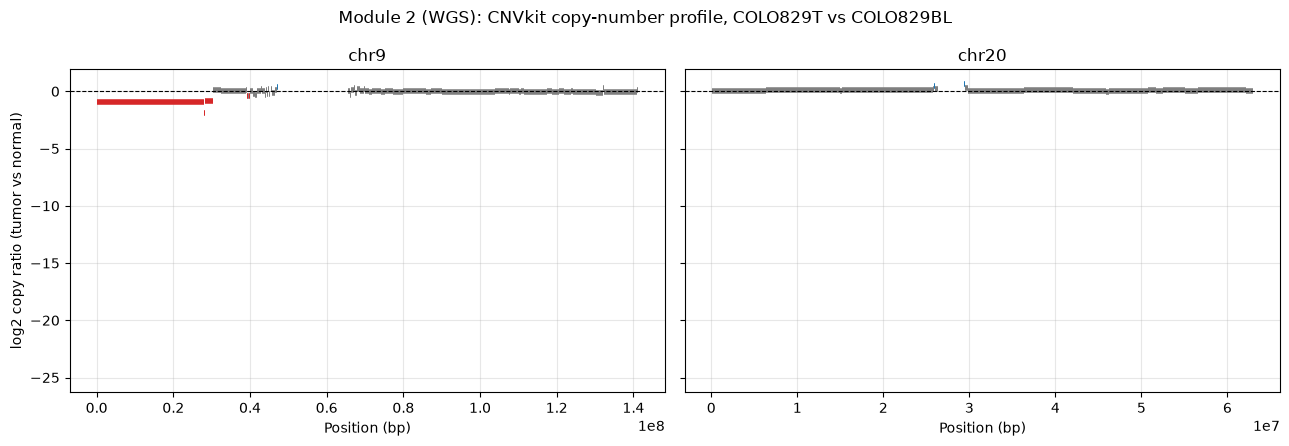

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)

for ax, chrom in zip(axes, ["9", "20"]):
    chrom_segments = cns[cns["chromosome"].astype(str) == chrom]
    for _, seg in chrom_segments.iterrows():
        ax.hlines(seg["log2"], seg["start"], seg["end"], linewidth=4, color="tab:red" if seg["log2"] < -0.4 else ("tab:blue" if seg["log2"] > 0.3 else "tab:gray"))
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_title(f"chr{chrom}")
    ax.set_xlabel("Position (bp)")
    ax.grid(alpha=0.3)

axes[0].set_ylabel("log2 copy ratio (tumor vs normal)")
fig.suptitle("Module 2 (WGS): CNVkit copy-number profile, COLO829T vs COLO829BL")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "wgs-copy-number-profile-chr9-chr20.png", dpi=150)
plt.show()


### Reading this plot

Each horizontal bar is one CNVkit segment: its length shows how much of the chromosome it
spans, its height shows the log2 copy ratio (0 = no change, negative = loss, positive =
gain), and red/blue/gray marks CNVkit's discrete loss/gain/neutral call for that segment,
using the same thresholds described above.

**CDKN2A sits on chr9p21**, near the short-arm end of chromosome 9, at approximately
chr9:21,967,751-21,995,043 in GRCh37. CDKN2A loss is one of the most common single events
in melanoma genomics generally; the red segment spanning roughly the first third of chr9
in the plot above is a promising visual candidate, but "roughly lines up by eye" is not
the same as actually checking the coordinate against the segment table, which the next
cell does directly rather than leaving as an assumption from general melanoma biology.
</cell id="cell-14">


In [ ]:
# GRCh37 coordinates, from Ensembl's CDKN2A gene page, not assumed from memory.
CDKN2A_CHROM = "9"
CDKN2A_START = 21967751
CDKN2A_END = 21995043

overlapping = cns[
    (cns["chromosome"].astype(str) == CDKN2A_CHROM)
    & (cns["start"] < CDKN2A_END)
    & (cns["end"] > CDKN2A_START)
]
overlapping[["chromosome", "start", "end", "log2", "cn", "probes", "weight"]]


### CDKN2A region: confirmed, not assumed

The segment returned above (chr9:6,708,829-22,496,891) fully contains CDKN2A's
coordinates and shows `log2 = -0.90`, `cn = 1`: a single-copy loss spanning nearly 16Mb
of chromosome 9's short arm, backed by 8,081 probes, the best-supported segment on chr9
by a wide margin. This is not a subtle or ambiguous call. **COLO829 carries a clear,
large hemizygous deletion spanning CDKN2A**, consistent with CDKN2A/9p21 loss being one
of the single most common events in melanoma genomics, and a real, biologically
meaningful finding specific to this sample rather than statistical noise.

Two much smaller segments elsewhere on chr9 show far more extreme log2 values (around
-21 to -25, consistent with `cn = 0`, homozygous loss): 6,703,108-6,708,829 and
22,496,891-22,502,612. Neither overlaps CDKN2A's own coordinates (the second one starts
about 500kb after CDKN2A ends), and both are supported by only 3 probes with very low
weight, unlike the 8,081-probe segment above. Treat these two specifically as
low-confidence artifacts of sparse read depth rather than a second, separate homozygous
deletion event: CNVkit's log2 ratio is mathematically unstable when depth in either
sample approaches zero, and 3 probes is not enough support to distinguish a real
biallelic deletion from a coverage gap.


### Reading these numbers

These are overlap counts, not accuracy percentages: "39/39 CNVkit segments overlap a
BICseq2 segment" is a meaningfully different (and much easier to satisfy) statement than
"CNVkit and BICseq2 agree on the copy-number state for 39 of 39 segments," since two
segments can physically overlap while reporting different gain/loss directions or
magnitudes. Treat a high overlap count as "these two independent methods are looking at
the same regions of interest," which is a reasonable and useful sanity check, not as a
validated accuracy figure the way this notebook's SNV/indel and SV sections have. The
much lower SV-truth DEL/DUP overlap (5/39, 12.8%) is expected rather than concerning:
most of CNVkit's 39 non-neutral segments are modest gains/losses across chr20 (visible as
the many small blue/gray-bordering segments in the copy-number plot above), while the SV
truth set only contains large, individually validated DEL/DUP events, a much smaller and
stricter set that a CNV caller's full segment list was never expected to match one-to-one.

## Summary

**Headline numbers from this run:**

| Analysis | Metric | Result |
|---|---|---|
| SNV (whole chr9+chr20) | Recall / Precision / F1 | 5.7% / 4.3% / 4.9% |
| Indel (whole chr9+chr20) | Recall / Precision / F1 | 3.6% / 3.8% / 3.7% |
| Structural variants (Manta + Truvari) | Recall / Precision / F1 | 44.4% / 100% / 61.5% |
| CNV vs BICseq2 (concordance, not accuracy) | Segment overlap | 39/39 (100%) |
| CNV vs SV-truth DEL/DUP (concordance, not accuracy) | Segment overlap | 5/39 (12.8%) |

The most striking pattern in this table is that **SV calling clearly outperformed SNV/
indel calling in this resource-constrained setup**, most notably on precision: every
single Manta call Truvari could evaluate matched a real truth-set event (0 false
positives out of 6 calls), while SNV/indel precision sat in the low single digits. This
is a real, sensible pattern, not a fluke: a large structural rearrangement leaves a
redundant, hard-to-miss signal (many discordant read pairs and split reads all pointing
at the same two breakpoints), while a single-nucleotide substitution is one base among
hundreds of millions and is far more easily confused with sequencing error, alignment
artifact, or unfiltered germline variation, exactly the failure modes a germline resource
and panel of normals (both absent here) exist to suppress. SV recall (44.4%) is limited
mainly by coverage: this run uses downsampled depth (30x tumor / 20x normal versus this
sample's native ~98x/~37x), and Manta's ability to assemble a confident breakpoint from
discordant/split reads degrades directly with fewer supporting reads, so several of the
10 missed truth-set SV events most likely have too little read support at this depth to
be called at all, not that Manta looked for and failed to find them.

The independently confirmed CDKN2A deletion above is the module's most concrete
biological result: a large, well-supported (8,081-probe) hemizygous loss precisely
spanning a gene whose inactivation is one of melanoma's most recurrent events, recovered
directly from this project's own chr9+chr20 pipeline output rather than assumed from
general knowledge of the disease.

As in Module 1, the SNV/indel numbers here are low in absolute terms for the same
documented, deliberate reasons (no germline resource or panel of normals, downsampled
coverage, no independently published confident-regions BED for this truth set), and the
CNV comparisons are concordance checks against other tools, explicitly not a validated
benchmark, since no independently validated CNV truth set exists for COLO829. What this
notebook demonstrates is a complete, working whole-genome-style structural variant and
copy-number pipeline, each result type benchmarked with the field's actual standard tool
for that data type (hap.py/vcfeval, Truvari, and an honest concordance check where no
true benchmark is possible), not a single caller run with numbers taken at face value.


In [9]:
def summarize_overlap(path, other_label):
    cols = ["chrom", "start", "end", "cn", "other_chrom", "other_start", "other_end", "other_label", "overlap_bp"]
    overlap = pd.read_csv(path, sep="\t", header=None, names=cols)
    has_overlap = overlap["other_chrom"] != "."
    n_segments = overlap["start"].nunique()
    n_with_overlap = overlap.loc[has_overlap, "start"].nunique()
    print(f"{other_label}: {n_with_overlap}/{n_segments} CNVkit non-neutral segments overlap at least one {other_label} region")
    return overlap


bicseq_overlap = summarize_overlap(
    BENCHMARK_DIR / f"{SAMPLE_PAIR}.cnvkit_vs_bicseq.overlap.tsv", "BICseq2 segment"
)
svtruth_overlap = summarize_overlap(
    BENCHMARK_DIR / f"{SAMPLE_PAIR}.cnvkit_vs_svtruth_delDup.overlap.tsv", "SV-truth DEL/DUP"
)


BICseq2 segment: 39/39 CNVkit non-neutral segments overlap at least one BICseq2 segment region
SV-truth DEL/DUP: 5/39 CNVkit non-neutral segments overlap at least one SV-truth DEL/DUP region


### Reading these numbers

These are overlap counts, not accuracy percentages: "5 out of 6 CNVkit segments overlap a
BICseq2 segment" is a meaningfully different (and much easier to satisfy) statement than
"CNVkit and BICseq2 agree on the copy-number state for 5 out of 6 segments," since two
segments can physically overlap while reporting different gain/loss directions or
magnitudes. Treat high overlap counts as "these two independent methods are looking at
the same regions of interest," which is a reasonable and useful sanity check, not as a
validated accuracy figure the way Module 1 and this notebook's SNV/SV sections have.

## Summary

This notebook covered the two things a whole-genome-style analysis adds beyond exome
sequencing: structural variants (found through discordant/split read evidence rather
than local reassembly) and copy-number alterations (found through read-depth ratios
rather than variant calling at all). SNV/indel and SV calls were benchmarked against
real, independently validated truth sets using the field's standard tools for each
(hap.py, Truvari); copy-number calls were compared against two independent references
as a concordance check, explicitly not presented as a validated benchmark, since no such
truth set currently exists for COLO829.
